# Lawsuit Classifier Comparison — Diagnostic Plots

Visual diagnostics for the model comparison run by `scripts/compare_classifiers.py`:
ROC curves, precision-recall curves, confusion matrices, and threshold sensitivity,
for every `feature+head` configuration (e.g. `tfidf+logreg`, `bert_frozen+xgboost`,
`bert_finetuned+nn`) on the **same shared test split**.

**Inputs** (regenerate with `uv run python scripts/compare_classifiers.py`):
- `data/classification/model_comparison.json` — aggregate metrics + run metadata
- `data/classification/model_comparison_predictions.npz` — per-config test-set
  probabilities + true labels (what the aggregate metrics can't show you)

If a config is missing here, it was skipped in that run (e.g. via
`--skip-bert-finetune` / `--skip-bert-frozen`) — rerun without those flags to include it.

Sections 1-6 compare feature/head configs on one training run each. Sections 7+ switch
to the **bootstrap ensemble** (`scripts/train_bert_classifier.py --bootstrap-iterations N`)
— many independently trained BERT models — to look at bagged performance and
**run-to-run model stability**, which a single training run can't show.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    auc,
    f1_score,
    precision_recall_curve,
    roc_curve,
)

plt.rcParams["figure.figsize"] = (9, 4.5)

DATA_ROOT = Path("..") / "data" / "classification"
METRICS_PATH = DATA_ROOT / "model_comparison.json"
PREDICTIONS_PATH = DATA_ROOT / "model_comparison_predictions.npz"

with open(METRICS_PATH) as f:
    comparison = json.load(f)

metadata = comparison["metadata"]
results = comparison["results"]

npz = np.load(PREDICTIONS_PATH, allow_pickle=True)
categories = list(npz["categories"])
y_test = npz["y_test"]
probas = {
    key[len("proba__"):]: npz[key]
    for key in npz.files
    if key.startswith("proba__")
}
config_names = sorted(probas.keys())

print(f"Categories: {categories}")
print(f"Test set size: {y_test.shape[0]}")
print(f"Configs available: {config_names}")

# Stable color per config across every plot below
cmap = plt.get_cmap("tab10")
config_color = {name: cmap(i % 10) for i, name in enumerate(config_names)}


Categories: ['product_liability', 'personal_injury']
Test set size: 136
Configs available: ['tfidf+logreg', 'tfidf+random_forest', 'tfidf+xgboost']


## 1. Aggregate metrics (from `model_comparison.json`)

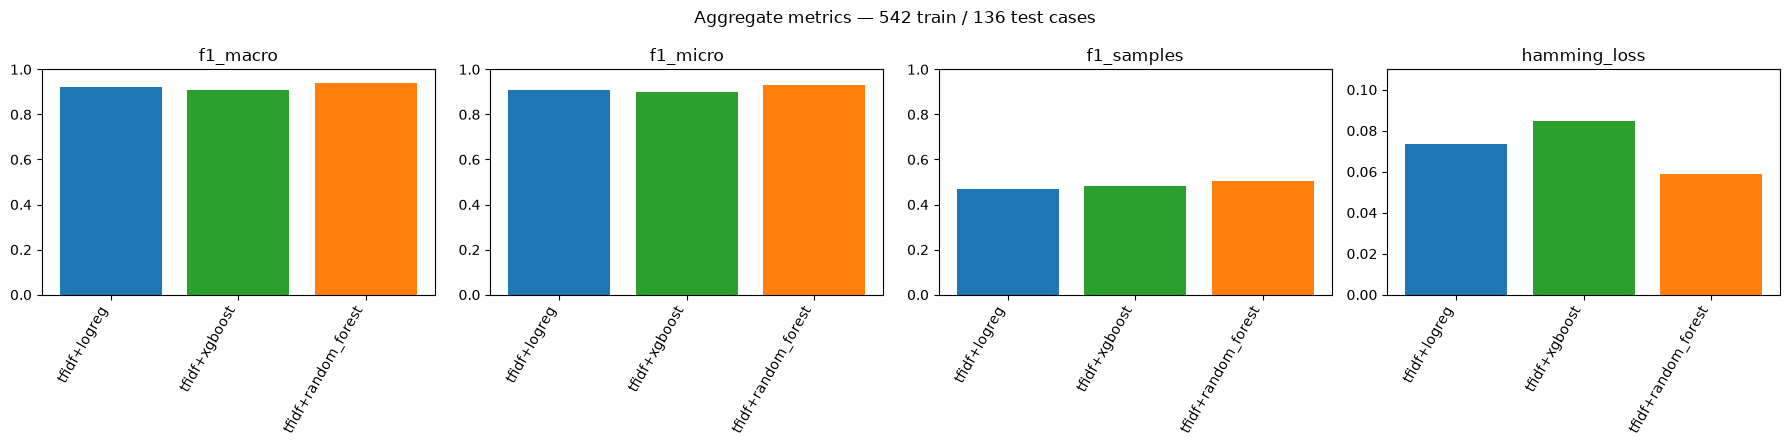

In [2]:
metric_names = ["f1_macro", "f1_micro", "f1_samples", "hamming_loss"]
fig, axes = plt.subplots(1, len(metric_names), figsize=(18, 4.5))
configs = list(results.keys())
x = np.arange(len(configs))

for ax, metric in zip(axes, metric_names):
    values = [results[c][metric] for c in configs]
    colors = [config_color.get(c, "#999999") for c in configs]
    ax.bar(x, values, color=colors)
    ax.set_xticks(x)
    ax.set_xticklabels(configs, rotation=60, ha="right")
    ax.set_title(metric)
    ax.set_ylim(0, 1 if metric != "hamming_loss" else max(values) * 1.3)

fig.suptitle(f"Aggregate metrics — {metadata['n_train']} train / {metadata['n_test']} test cases")
fig.tight_layout()
plt.show()


## 2. ROC curves (per category, all configs overlaid)

One panel per category. Each line is one `feature+head` config; AUC in the legend.
Diagonal = random guessing.


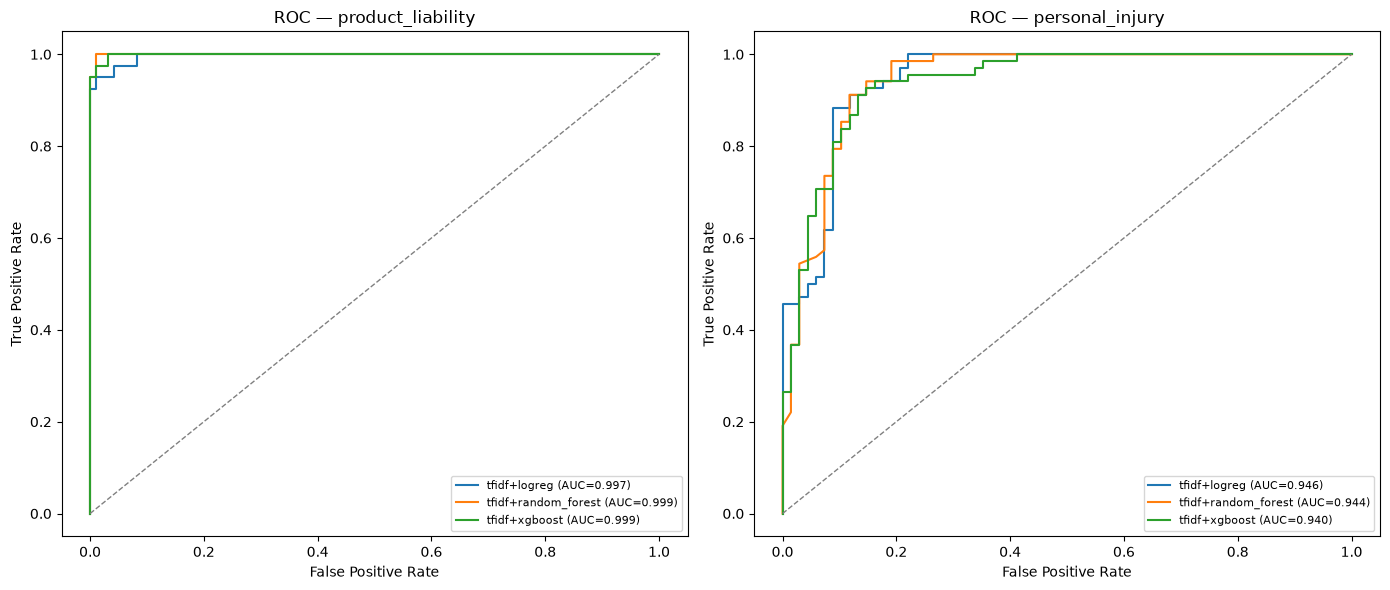

In [3]:
fig, axes = plt.subplots(1, len(categories), figsize=(7 * len(categories), 6))
if len(categories) == 1:
    axes = [axes]

for cat_idx, (ax, category) in enumerate(zip(axes, categories)):
    y_true_cat = y_test[:, cat_idx]
    for name in config_names:
        y_score = probas[name][:, cat_idx]
        fpr, tpr, _ = roc_curve(y_true_cat, y_score)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=config_color[name], label=f"{name} (AUC={roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC — {category}")
    ax.legend(fontsize=8, loc="lower right")

fig.tight_layout()
plt.show()


## 3. Precision-Recall curves (per category, all configs overlaid)

More informative than ROC when positives are imbalanced (`product_liability` is ~29%
of cases, `personal_injury` ~50% here) — PR curves don't get flattered by the large
number of true negatives the way ROC/AUC can.


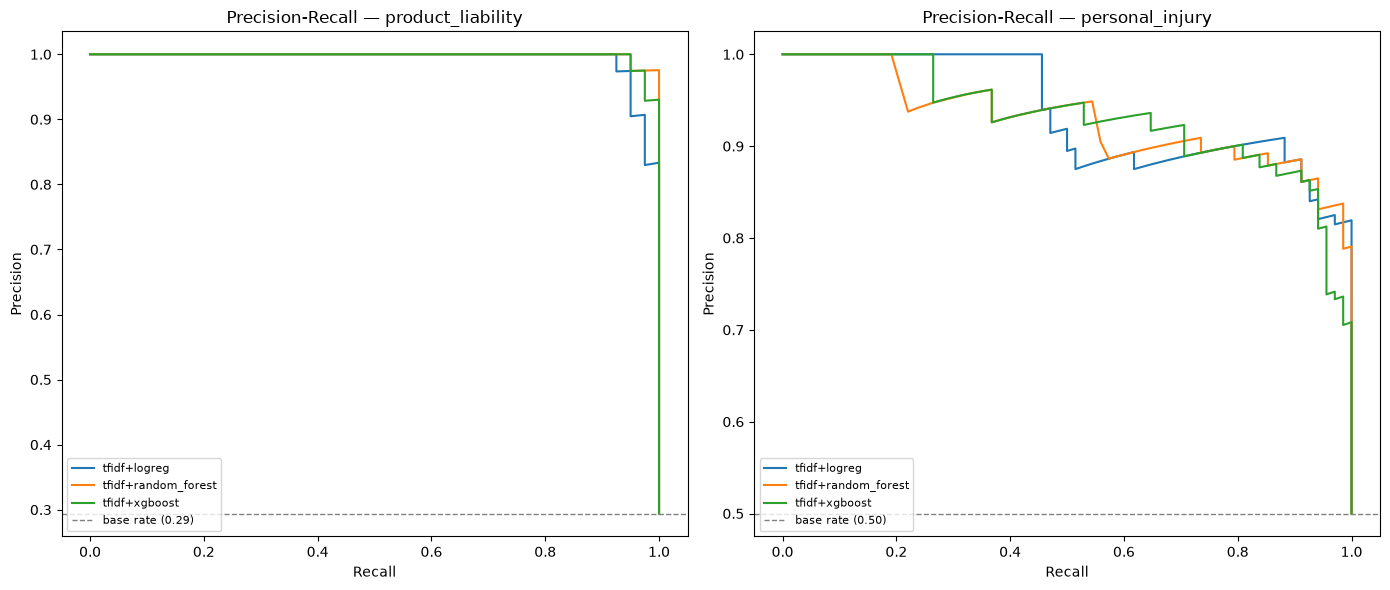

In [4]:
fig, axes = plt.subplots(1, len(categories), figsize=(7 * len(categories), 6))
if len(categories) == 1:
    axes = [axes]

for cat_idx, (ax, category) in enumerate(zip(axes, categories)):
    y_true_cat = y_test[:, cat_idx]
    base_rate = y_true_cat.mean()
    for name in config_names:
        y_score = probas[name][:, cat_idx]
        precision, recall, _ = precision_recall_curve(y_true_cat, y_score)
        ax.plot(recall, precision, color=config_color[name], label=name)
    ax.axhline(base_rate, linestyle="--", color="gray", linewidth=1, label=f"base rate ({base_rate:.2f})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"Precision-Recall — {category}")
    ax.legend(fontsize=8, loc="lower left")

fig.tight_layout()
plt.show()


## 4. Confusion matrices (threshold = 0.5)

Rows = config, columns = category.


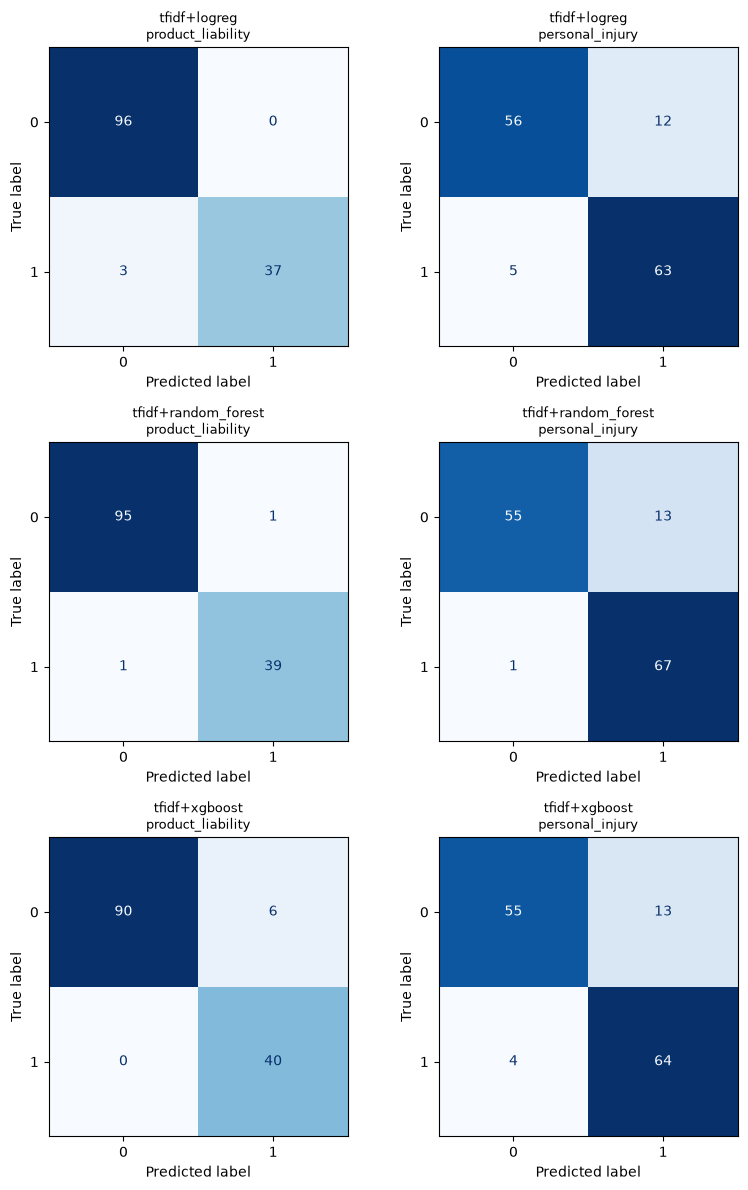

In [5]:
fig, axes = plt.subplots(len(config_names), len(categories), figsize=(4 * len(categories), 4 * len(config_names)))
if len(config_names) == 1:
    axes = axes[None, :]
if len(categories) == 1:
    axes = axes[:, None]

for row, name in enumerate(config_names):
    for col, category in enumerate(categories):
        y_true_cat = y_test[:, col]
        y_pred_cat = (probas[name][:, col] > 0.5).astype(int)
        ConfusionMatrixDisplay.from_predictions(
            y_true_cat, y_pred_cat, ax=axes[row, col], colorbar=False, cmap="Blues"
        )
        axes[row, col].set_title(f"{name}\n{category}", fontsize=9)

fig.tight_layout()
plt.show()


## 5. Threshold sensitivity (F1 vs. decision threshold)

The comparison script uses a fixed 0.5 cutoff. This shows whether a different
threshold would materially help a given config/category — useful for the rarer
category, where 0.5 is not necessarily optimal for F1.


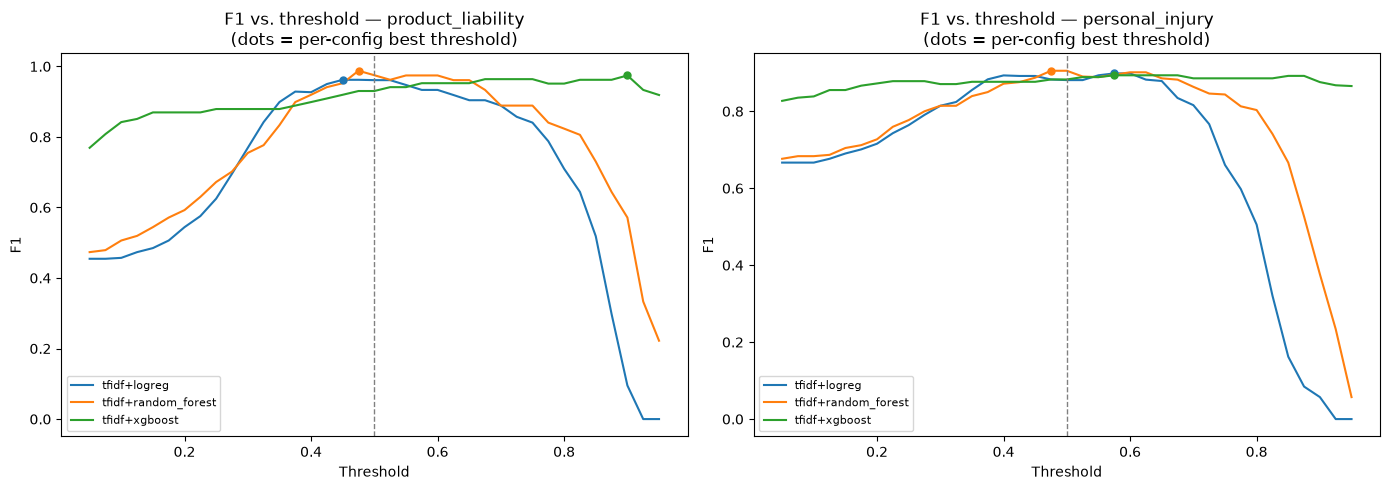

In [6]:
thresholds = np.linspace(0.05, 0.95, 37)

fig, axes = plt.subplots(1, len(categories), figsize=(7 * len(categories), 5))
if len(categories) == 1:
    axes = [axes]

for cat_idx, (ax, category) in enumerate(zip(axes, categories)):
    y_true_cat = y_test[:, cat_idx]
    for name in config_names:
        y_score = probas[name][:, cat_idx]
        f1s = [f1_score(y_true_cat, (y_score > t).astype(int), zero_division=0) for t in thresholds]
        ax.plot(thresholds, f1s, color=config_color[name], label=name)
        best_t = thresholds[int(np.argmax(f1s))]
        ax.scatter([best_t], [max(f1s)], color=config_color[name], marker="o", s=25, zorder=5)
    ax.axvline(0.5, linestyle="--", color="gray", linewidth=1)
    ax.set_xlabel("Threshold")
    ax.set_ylabel("F1")
    ax.set_title(f"F1 vs. threshold — {category}\n(dots = per-config best threshold)")
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()


## 6. Calibration (reliability diagrams)

Do predicted probabilities mean what they say (e.g. among cases scored ~0.7, are ~70%
actually positive)? Only meaningful for probability-based downstream decisions
(e.g. flagging cases for review by score), not for the F1 metrics above.


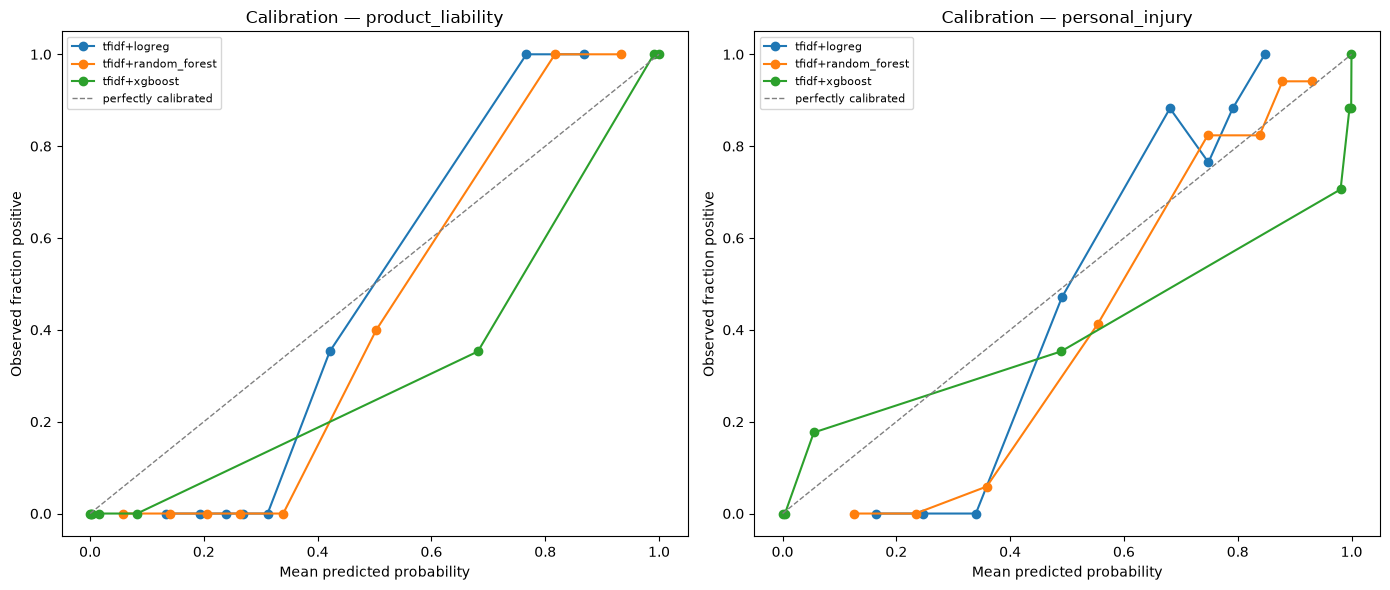

In [7]:
fig, axes = plt.subplots(1, len(categories), figsize=(7 * len(categories), 6))
if len(categories) == 1:
    axes = [axes]

for cat_idx, (ax, category) in enumerate(zip(axes, categories)):
    y_true_cat = y_test[:, cat_idx]
    for name in config_names:
        y_score = probas[name][:, cat_idx]
        frac_pos, mean_pred = calibration_curve(y_true_cat, y_score, n_bins=8, strategy="quantile")
        ax.plot(mean_pred, frac_pos, marker="o", color=config_color[name], label=name)
    ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="perfectly calibrated")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed fraction positive")
    ax.set_title(f"Calibration — {category}")
    ax.legend(fontsize=8, loc="upper left")

fig.tight_layout()
plt.show()


## 7. Bootstrap ensemble — load results

Diagnostics for the **bootstrap ensemble** trained by
`scripts/train_bert_classifier.py --bootstrap-iterations N` — `N` independent BERT
models, each fit on its own bootstrap resample (draw-with-replacement) of the training
set, all evaluated on the *same* held-out test split. This section answers two things
sections 1-6 can't:
- **Bagging**: does averaging predictions across models beat any single training run?
- **Stability**: how much do performance and individual predictions vary just from
  resampling + training stochasticity, independent of any real signal?

**Inputs** (regenerate with `uv run python scripts/train_bert_classifier.py
--bootstrap-iterations N`):
- `data/classification_bootstrap_models/ensemble_report.json` — bagged metrics +
  per-category uncertainty summary
- `data/classification_bootstrap_models/bootstrap_XXXX/{test_logits,test_labels}.npy` —
  per-iteration raw logits/labels on the shared test split

This run's categories/test split are independent of the `model_comparison.json` run
above (e.g. it may include `class_action`, excluded there for lack of data) — treat the
two sections as separate experiments, not a like-for-like comparison.

In [8]:
from sklearn.metrics import hamming_loss

BOOTSTRAP_DIR = DATA_ROOT.parent / "classification_bootstrap_models"
ENSEMBLE_REPORT_PATH = BOOTSTRAP_DIR / "ensemble_report.json"

with open(ENSEMBLE_REPORT_PATH) as f:
    ensemble_report = json.load(f)

bootstrap_categories = ensemble_report["categories"]
n_iterations = ensemble_report["n_iterations"]
bagged_metrics = ensemble_report["raw_metrics"]

run_dirs = sorted(
    d for d in BOOTSTRAP_DIR.glob("bootstrap_*")
    if (d / "DONE").exists()
)
assert len(run_dirs) == n_iterations, (
    f"ensemble_report says {n_iterations} iterations but found "
    f"{len(run_dirs)} completed bootstrap_XXXX dirs"
)

test_logits_stack = np.stack([np.load(d / "test_logits.npy") for d in run_dirs])  # (B, N, C)
test_labels_boot = np.load(run_dirs[0] / "test_labels.npy")  # (N, C) - same test split every iteration
for d in run_dirs[1:]:
    assert np.array_equal(np.load(d / "test_labels.npy"), test_labels_boot), (
        f"{d} was evaluated on a different test split than {run_dirs[0]}"
    )

test_probs_stack = 1 / (1 + np.exp(-test_logits_stack))  # (B, N, C)

# Distinct color per category, kept stable across the plots below
cmap_boot = plt.get_cmap("tab10")
category_color = {cat: cmap_boot(i % 10) for i, cat in enumerate(bootstrap_categories)}

print(f"Bootstrap iterations: {n_iterations}")
print(f"Categories: {bootstrap_categories}")
print(f"Test set size: {test_labels_boot.shape[0]}")
print(
    "Positives per category: "
    f"{dict(zip(bootstrap_categories, test_labels_boot.sum(axis=0).astype(int).tolist()))}"
)


Bootstrap iterations: 100
Categories: ['product_liability', 'personal_injury', 'class_action']
Test set size: 148
Positives per category: {'product_liability': 44, 'personal_injury': 73, 'class_action': 7}


## 8. Bagged ensemble vs. a single training run

Each bootstrap iteration is a *full independent* training run (its own resample +
weight init). The box below is how much a single run's metric would vary if you only
trained once; the dashed line is what the bagged ensemble (mean predicted probability
across all `n_iterations` models) actually achieves — bagging should sit at or above
the single-run distribution, not inside its noisy tail.

/tmp/ipykernel_16458/1851526795.py:23: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(values, vert=True, widths=0.5, showmeans=True)
/tmp/ipykernel_16458/1851526795.py:23: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(values, vert=True, widths=0.5, showmeans=True)
/tmp/ipykernel_16458/1851526795.py:23: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(values, vert=True, widths=0.5, showmeans=True)
/tmp/ipykernel_16458/1851526795.py:23: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(values, vert=True, widt

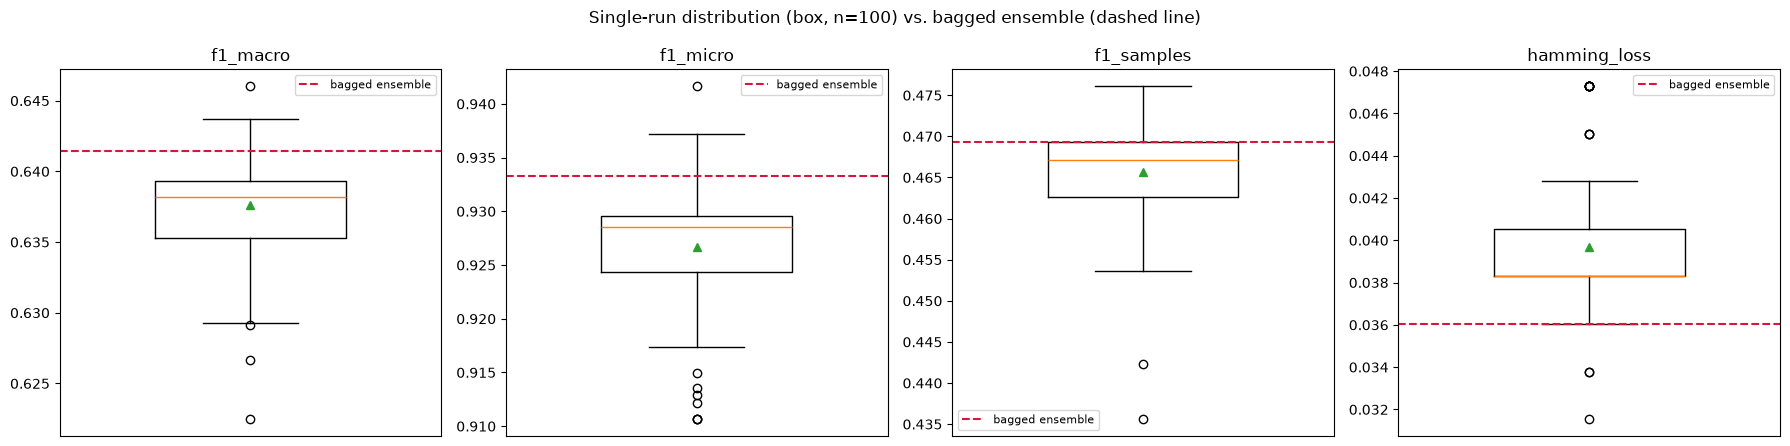

Single-run metric spread (mean ± std across 100 independently trained models):
  f1_macro: 0.6376 ± 0.0039  (bagged: 0.6415)
  f1_micro: 0.9267 ± 0.0061  (bagged: 0.9333)
  f1_samples: 0.4657 ± 0.0066  (bagged: 0.4694)
  hamming_loss: 0.0397 ± 0.0033  (bagged: 0.0360)


In [9]:
def metrics_from_probs_local(probs, labels, cats, threshold=0.5):
    preds = (probs > threshold).astype(float)
    m = {
        "hamming_loss": hamming_loss(labels, preds),
        "f1_micro": f1_score(labels, preds, average="micro", zero_division=0),
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        "f1_samples": f1_score(labels, preds, average="samples", zero_division=0),
    }
    for idx, cat in enumerate(cats):
        m[f"f1_{cat}"] = f1_score(labels[:, idx], preds[:, idx], zero_division=0)
    return m


per_iter_metrics = [
    metrics_from_probs_local(test_probs_stack[b], test_labels_boot, bootstrap_categories)
    for b in range(n_iterations)
]

metric_names_boot = ["f1_macro", "f1_micro", "f1_samples", "hamming_loss"]
fig, axes = plt.subplots(1, len(metric_names_boot), figsize=(18, 4.5))
for ax, metric in zip(axes, metric_names_boot):
    values = [m[metric] for m in per_iter_metrics]
    ax.boxplot(values, vert=True, widths=0.5, showmeans=True)
    ax.axhline(bagged_metrics[metric], color="crimson", linestyle="--", linewidth=1.5, label="bagged ensemble")
    ax.set_xticks([])
    ax.set_title(metric)
    ax.legend(fontsize=8)
fig.suptitle(f"Single-run distribution (box, n={n_iterations}) vs. bagged ensemble (dashed line)")
fig.tight_layout()
plt.show()

print(f"Single-run metric spread (mean ± std across {n_iterations} independently trained models):")
for metric in metric_names_boot:
    vals = np.array([m[metric] for m in per_iter_metrics])
    print(f"  {metric}: {vals.mean():.4f} ± {vals.std():.4f}  (bagged: {bagged_metrics[metric]:.4f})")


## 9. Per-category stability across bootstrap models

Same idea, broken out per category. A category that has collapsed to near-constant
base-rate predictions (a known failure mode here for `class_action` on a small sample —
see project notes) shows up as F1 pinned near zero with little spread; a category with
real signal shows a tighter, non-trivial distribution and a bagged (diamond) point that
sits at or above the single-run cloud.

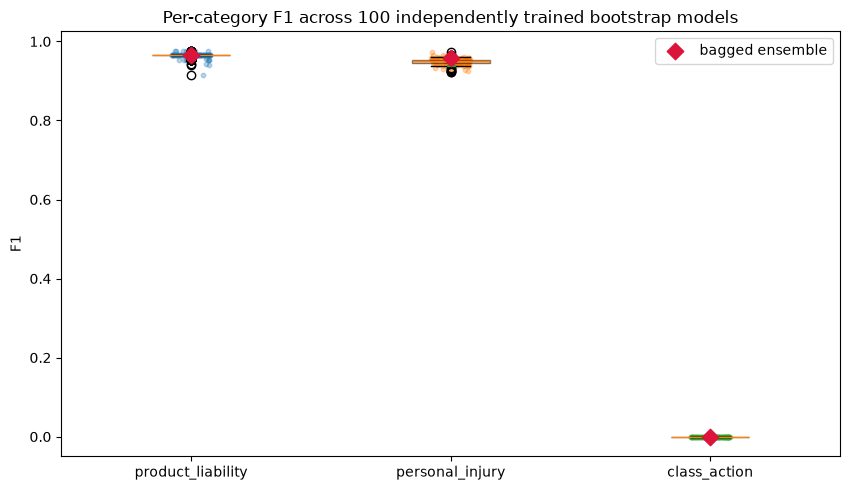

In [10]:
fig, ax = plt.subplots(figsize=(2.2 * len(bootstrap_categories) + 2, 5))
box_data = [[m[f"f1_{cat}"] for m in per_iter_metrics] for cat in bootstrap_categories]
bp = ax.boxplot(box_data, tick_labels=bootstrap_categories, showmeans=True, patch_artist=True)
for patch, cat in zip(bp["boxes"], bootstrap_categories):
    patch.set_facecolor(category_color[cat])
    patch.set_alpha(0.5)

for i, cat in enumerate(bootstrap_categories):
    jitter = (np.random.default_rng(0).random(n_iterations) - 0.5) * 0.15
    ax.scatter(i + 1 + jitter, box_data[i], color=category_color[cat], alpha=0.3, s=10)
    ax.scatter(
        [i + 1], [bagged_metrics[f"f1_{cat}"]], color="crimson", marker="D", zorder=5, s=70,
        label="bagged ensemble" if i == 0 else None,
    )

ax.set_ylabel("F1")
ax.set_title(f"Per-category F1 across {n_iterations} independently trained bootstrap models")
ax.legend()
fig.tight_layout()
plt.show()


## 10. Case-level prediction uncertainty

For every test case, the ensemble gives `n_iterations` probability estimates per
category instead of one. The mean is the bagged prediction; the standard deviation
is how much that prediction would have moved under a different bootstrap draw — high
std means the ensemble itself disagrees with itself, independent of whether the mean
prediction is correct. Expect disagreement to concentrate near the 0.5 decision
boundary; a cluster of high-std points far from 0.5 would flag cases the model is both
confident about *and* unstable on, which is worth a closer look.

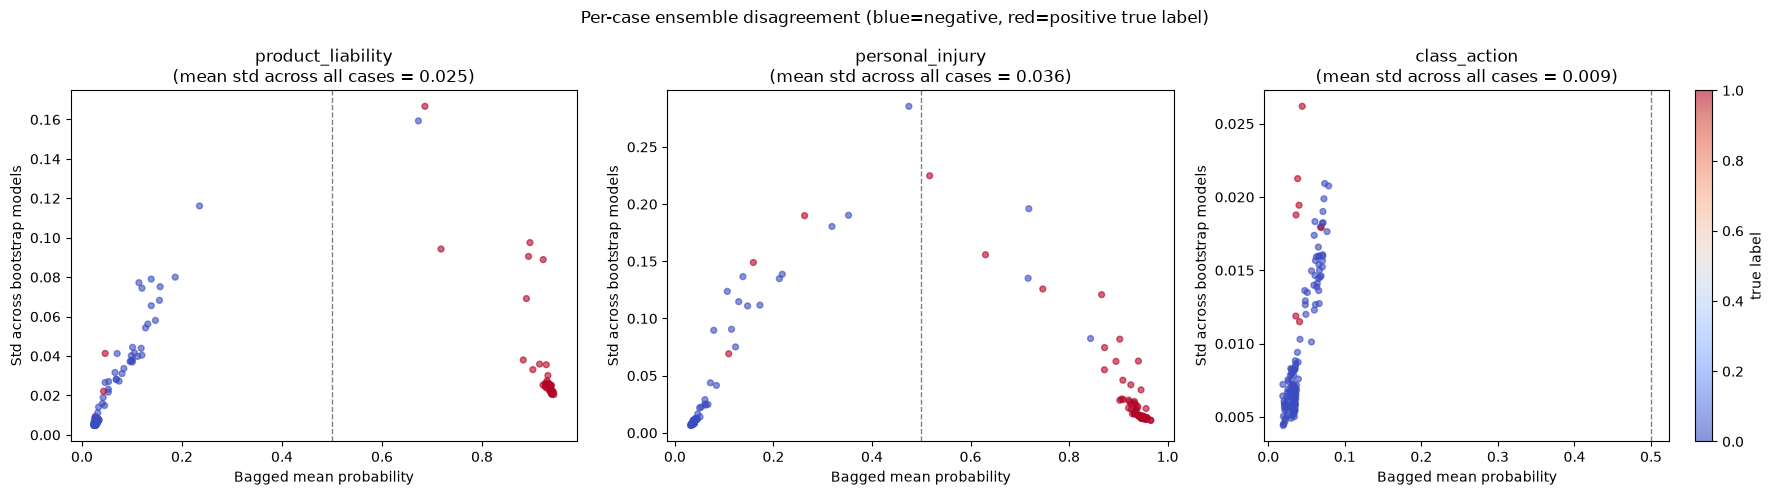

In [11]:
mean_probs = test_probs_stack.mean(axis=0)  # (N, C)
std_probs = test_probs_stack.std(axis=0)    # (N, C)

fig, axes = plt.subplots(1, len(bootstrap_categories), figsize=(6 * len(bootstrap_categories), 5))
if len(bootstrap_categories) == 1:
    axes = [axes]

for idx, (ax, cat) in enumerate(zip(axes, bootstrap_categories)):
    y_true_cat = test_labels_boot[:, idx]
    sc = ax.scatter(
        mean_probs[:, idx], std_probs[:, idx], c=y_true_cat, cmap="coolwarm",
        alpha=0.6, s=18, vmin=0, vmax=1,
    )
    ax.axvline(0.5, linestyle="--", color="gray", linewidth=1)
    ax.set_xlabel("Bagged mean probability")
    ax.set_ylabel("Std across bootstrap models")
    ax.set_title(f"{cat}\n(mean std across all cases = {std_probs[:, idx].mean():.3f})")

fig.colorbar(sc, ax=axes[-1], label="true label")
fig.suptitle("Per-case ensemble disagreement (blue=negative, red=positive true label)")
fig.tight_layout()
plt.show()


## 11. Prediction agreement (vote stability)

At threshold 0.5, what fraction of the `n_iterations` models predict positive for each
case? A value near 0 or 1 means the ensemble is unanimous — a resampling-stable
prediction. A value near 0.5 means individual models flip their prediction depending on
which bootstrap draw they happened to train on, i.e. the single-model prediction for
that case is close to a coin flip even though the bagged probability looks fine.

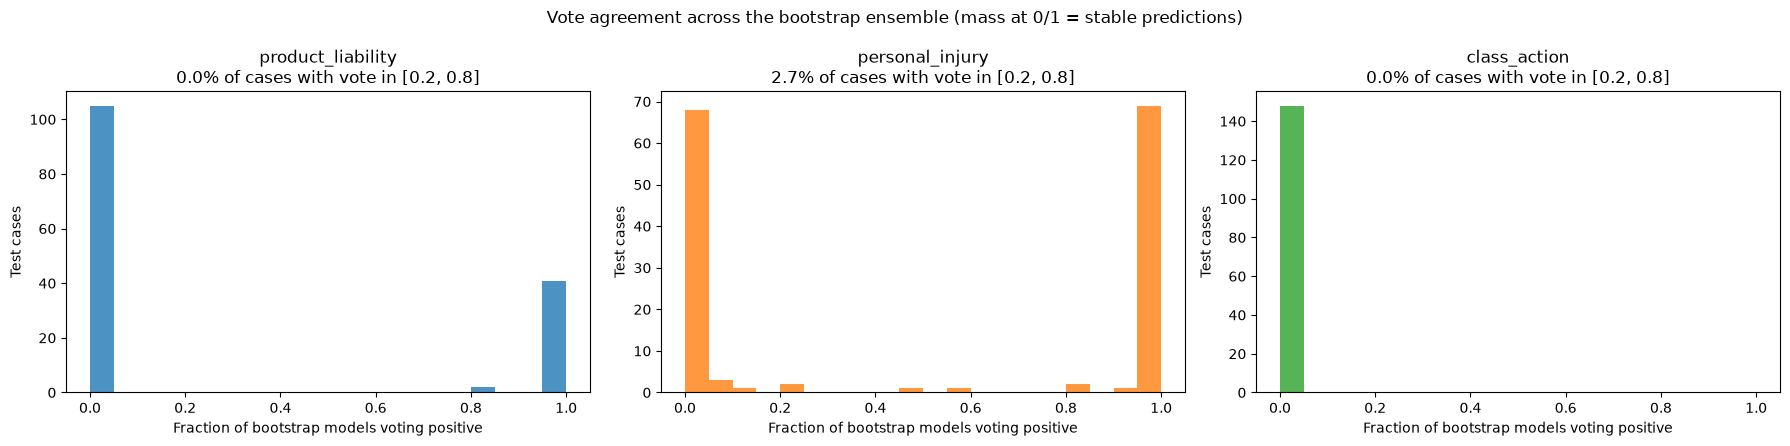

In [12]:
agreement = (test_probs_stack > 0.5).mean(axis=0)  # (N, C), fraction of models voting positive

fig, axes = plt.subplots(1, len(bootstrap_categories), figsize=(6 * len(bootstrap_categories), 4.5))
if len(bootstrap_categories) == 1:
    axes = [axes]

unstable_fraction = {}
for idx, (ax, cat) in enumerate(zip(axes, bootstrap_categories)):
    ax.hist(agreement[:, idx], bins=20, range=(0, 1), color=category_color[cat], alpha=0.8)
    unstable_fraction[cat] = float(((agreement[:, idx] > 0.2) & (agreement[:, idx] < 0.8)).mean())
    ax.set_title(f"{cat}\n{unstable_fraction[cat] * 100:.1f}% of cases with vote in [0.2, 0.8]")
    ax.set_xlabel("Fraction of bootstrap models voting positive")
    ax.set_ylabel("Test cases")

fig.suptitle("Vote agreement across the bootstrap ensemble (mass at 0/1 = stable predictions)")
fig.tight_layout()
plt.show()


## 12. Does the ensemble need all N models? (bagging convergence)

Cumulative bagged F1-macro as bootstrap models are added one at a time, averaged over
several random orderings (any ordering is equally valid since each model is an
independent draw). The curve should flatten once adding more models stops moving the
bagged prediction — that plateau point is roughly how many `--bootstrap-iterations`
are actually needed; running well past it mostly spends training time on tighter
uncertainty estimates (section 10/11), not better bagged accuracy.

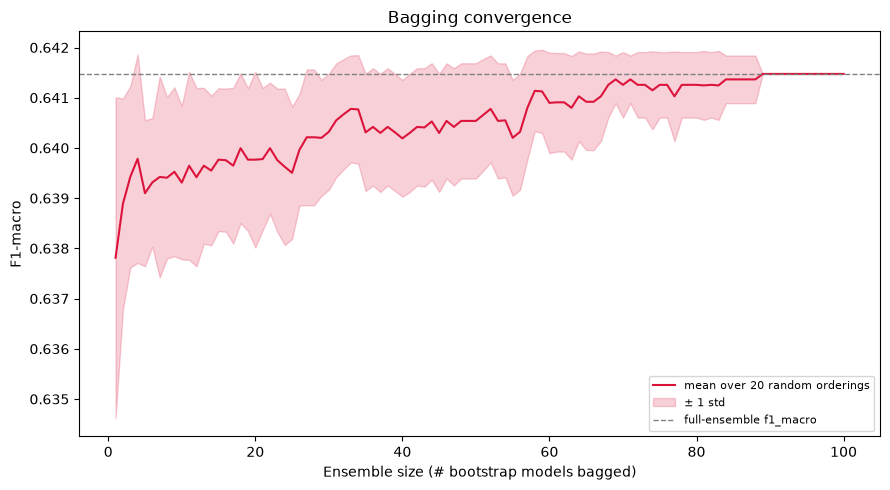

In [13]:
n_orderings = 20
rng = np.random.default_rng(0)
curves = np.zeros((n_orderings, n_iterations))

for o in range(n_orderings):
    order = rng.permutation(n_iterations)
    cum_probs = np.cumsum(test_probs_stack[order], axis=0) / np.arange(1, n_iterations + 1)[:, None, None]
    for k in range(n_iterations):
        preds = (cum_probs[k] > 0.5).astype(float)
        curves[o, k] = f1_score(test_labels_boot, preds, average="macro", zero_division=0)

mean_curve = curves.mean(axis=0)
std_curve = curves.std(axis=0)
ks = np.arange(1, n_iterations + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ks, mean_curve, color="crimson", label=f"mean over {n_orderings} random orderings")
ax.fill_between(ks, mean_curve - std_curve, mean_curve + std_curve, color="crimson", alpha=0.2, label="± 1 std")
ax.axhline(bagged_metrics["f1_macro"], color="gray", linestyle="--", linewidth=1, label="full-ensemble f1_macro")
ax.set_xlabel("Ensemble size (# bootstrap models bagged)")
ax.set_ylabel("F1-macro")
ax.set_title("Bagging convergence")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## 13. Summary

Data-driven recap of sections 8-11, computed from the values above rather than
hardcoded — safe to rerun after a new `--bootstrap-iterations` run.

In [14]:
print("=== Bootstrap ensemble summary ===")
print(f"{n_iterations} models, {test_labels_boot.shape[0]} shared test cases\n")

print("Bagged vs. mean single-run performance:")
for metric in metric_names_boot:
    vals = np.array([m[metric] for m in per_iter_metrics])
    delta = bagged_metrics[metric] - vals.mean()
    lower_is_better = metric == "hamming_loss"
    better = "better" if (delta < 0) == lower_is_better else "worse"
    print(
        f"  {metric}: bagged {bagged_metrics[metric]:.4f} vs. single-run mean "
        f"{vals.mean():.4f} ({delta:+.4f}, bagging is {better})"
    )

print("\nPer-category stability (std of F1 across independently trained models):")
for cat in bootstrap_categories:
    vals = np.array([m[f"f1_{cat}"] for m in per_iter_metrics])
    print(f"  {cat}: F1 {vals.mean():.4f} ± {vals.std():.4f} (min {vals.min():.4f}, max {vals.max():.4f})")

print("\nPer-category case-level disagreement (mean std of predicted probability, and % of")
print("cases with an unstable vote in [0.2, 0.8]):")
for idx, cat in enumerate(bootstrap_categories):
    print(f"  {cat}: std={std_probs[:, idx].mean():.4f}, unstable={unstable_fraction[cat] * 100:.1f}%")


=== Bootstrap ensemble summary ===
100 models, 148 shared test cases

Bagged vs. mean single-run performance:
  f1_macro: bagged 0.6415 vs. single-run mean 0.6376 (+0.0039, bagging is better)
  f1_micro: bagged 0.9333 vs. single-run mean 0.9267 (+0.0067, bagging is better)
  f1_samples: bagged 0.4694 vs. single-run mean 0.4657 (+0.0037, bagging is better)
  hamming_loss: bagged 0.0360 vs. single-run mean 0.0397 (-0.0036, bagging is better)

Per-category stability (std of F1 across independently trained models):
  product_liability: F1 0.9637 ± 0.0076 (min 0.9157, max 0.9767)
  personal_injury: F1 0.9490 ± 0.0092 (min 0.9220, max 0.9726)
  class_action: F1 0.0000 ± 0.0000 (min 0.0000, max 0.0000)

Per-category case-level disagreement (mean std of predicted probability, and % of
cases with an unstable vote in [0.2, 0.8]):
  product_liability: std=0.0251, unstable=0.0%
  personal_injury: std=0.0363, unstable=2.7%
  class_action: std=0.0094, unstable=0.0%
